# Predição de óbito por COVID-19

Este notebook desenvolve um pipeline completo de Machine Learning para prever a probabilidade de óbito em pacientes com COVID-19 a partir de variáveis clínicas estruturadas.

## Objetivo
- Construir um modelo classificador binário para estimar se um paciente provavelmente virá a óbito.
- Explorar o dataset, tratar valores ausentes e comparar modelos clássicos e de boosting.
- Produzir um modelo final interpretável e salvar em disco para uso posterior.

## Integrantes
- Gabriel Sant Ana - RM375211
- Lucas Faria Polaquini - RM375345
- Victor Luiz Domingues - RM375278


In [34]:
# Importa funções de sistema e tratamento de caminhos para localizar arquivos
from pathlib import Path

# Evita avisos de execução que não afetam o resultado do experimento
import warnings

# Bibliotecas para análise, visualização e manipulação de dados
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno

# Ferramentas de pré-processamento e modelagem para treinamento de classificadores
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, make_scorer, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_score, recall_score, f1_score, make_scorer
from sklearn.utils.class_weight import compute_sample_weight

# Reduz ruído na saída para manter o notebook mais limpo
warnings.filterwarnings('ignore')
# Define o estilo visual padrão dos gráficos
plt.style.use('seaborn-v0_8')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Definição do caminho do dataset
DATA_DIR = Path('data')
DATA_FILE = DATA_DIR / 'covid.csv'

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [23]:
# Carregamento do dataset
# O dataset público do Kaggle pode ser baixado para a pasta data/.
# Se o arquivo já estiver presente, este bloco o carrega diretamente.

if DATA_FILE.exists():
    df = pd.read_csv(DATA_FILE)
    print(f'Dataset carregado de {DATA_FILE}')
else:
    try:
        import kagglehub
        path = kagglehub.dataset_download('meirnizri/covid19-dataset')
        csv_files = list(Path(path).glob('*.csv'))
        if not csv_files:
            raise FileNotFoundError('Nenhum arquivo CSV encontrado no dataset baixado.')
        df = pd.read_csv(csv_files[0])
        DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(DATA_FILE, index=False)
        print(f'Dataset baixado e salvo em {DATA_FILE}')
    except Exception as exc:
        print(f'Falha ao baixar automaticamente: {exc}')
        print('Por favor, coloque o arquivo CSV na pasta data/ com o nome covid.csv.')
        df = None

if df is not None:
    display(df.head())
    print('\nFormato do dataset:', df.shape)
    print('\nTipos de colunas:')
    print(df.dtypes)

Dataset carregado de data\covid.csv


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97



Formato do dataset: (1048575, 21)

Tipos de colunas:
USMER                   int64
MEDICAL_UNIT            int64
SEX                     int64
PATIENT_TYPE            int64
DATE_DIED                 str
INTUBED                 int64
PNEUMONIA               int64
AGE                     int64
PREGNANT                int64
DIABETES                int64
COPD                    int64
ASTHMA                  int64
INMSUPR                 int64
HIPERTENSION            int64
OTHER_DISEASE           int64
CARDIOVASCULAR          int64
OBESITY                 int64
RENAL_CHRONIC           int64
TOBACCO                 int64
CLASIFFICATION_FINAL    int64
ICU                     int64
dtype: object


## 3. Carregamento do DS, Análise exploratória dos dados
Verificamos shape, tipos de dados e valores ausentes para garantir que o dataset está adequado.


In [25]:
# Mostra quantas linhas e colunas existem no conjunto de dados
print('\nInformações sobre os dados:')
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')



Informações sobre os dados:
Número de linhas: 1048575
Número de colunas: 21


In [26]:
# Exibe o tipo de cada coluna para verificar se há dados numéricos ou categóricos
print('\nTipos de dados:')
df.dtypes



Tipos de dados:


USMER                   int64
MEDICAL_UNIT            int64
SEX                     int64
PATIENT_TYPE            int64
DATE_DIED                 str
INTUBED                 int64
PNEUMONIA               int64
AGE                     int64
PREGNANT                int64
DIABETES                int64
COPD                    int64
ASTHMA                  int64
INMSUPR                 int64
HIPERTENSION            int64
OTHER_DISEASE           int64
CARDIOVASCULAR          int64
OBESITY                 int64
RENAL_CHRONIC           int64
TOBACCO                 int64
CLASIFFICATION_FINAL    int64
ICU                     int64
dtype: object

In [27]:
# Conta quantos valores únicos cada coluna possui para identificar variáveis categóricas ou quase constantes
print('\nNúmero de valores únicos por coluna:')
df.nunique()



Número de valores únicos por coluna:


USMER                     2
MEDICAL_UNIT             13
SEX                       2
PATIENT_TYPE              2
DATE_DIED               401
INTUBED                   4
PNEUMONIA                 3
AGE                     121
PREGNANT                  4
DIABETES                  3
COPD                      3
ASTHMA                    3
INMSUPR                   3
HIPERTENSION              3
OTHER_DISEASE             3
CARDIOVASCULAR            3
OBESITY                   3
RENAL_CHRONIC             3
TOBACCO                   3
CLASIFFICATION_FINAL      7
ICU                       4
dtype: int64

In [28]:
# Resume estatísticas básicas das colunas numéricas para entender a distribuição dos dados
print('\nAnálise das estatísticas dos dados:')
df.describe()



Análise das estatísticas dos dados:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [29]:
# Mostra as primeiras linhas para validar rapidamente o conteúdo carregado
print('\nAmostra das top linhas:')
df.head()



Amostra das top linhas:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [30]:
# Mostra as últimas linhas para conferir se o carregamento terminou corretamente
print('\nAmostra das ultimas linhas:')
df.tail()



Amostra das ultimas linhas:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
1048570,2,13,2,1,9999-99-99,97,2,40,97,2,...,2,2,2,2,2,2,2,2,7,97
1048571,1,13,2,2,9999-99-99,2,2,51,97,2,...,2,2,1,2,2,2,2,2,7,2
1048572,2,13,2,1,9999-99-99,97,2,55,97,2,...,2,2,2,2,2,2,2,2,7,97
1048573,2,13,2,1,9999-99-99,97,2,28,97,2,...,2,2,2,2,2,2,2,2,7,97
1048574,2,13,2,1,9999-99-99,97,2,52,97,2,...,2,2,2,2,2,2,2,2,7,97



Matriz de valores ausentes e Valores ausentes por coluna:


USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

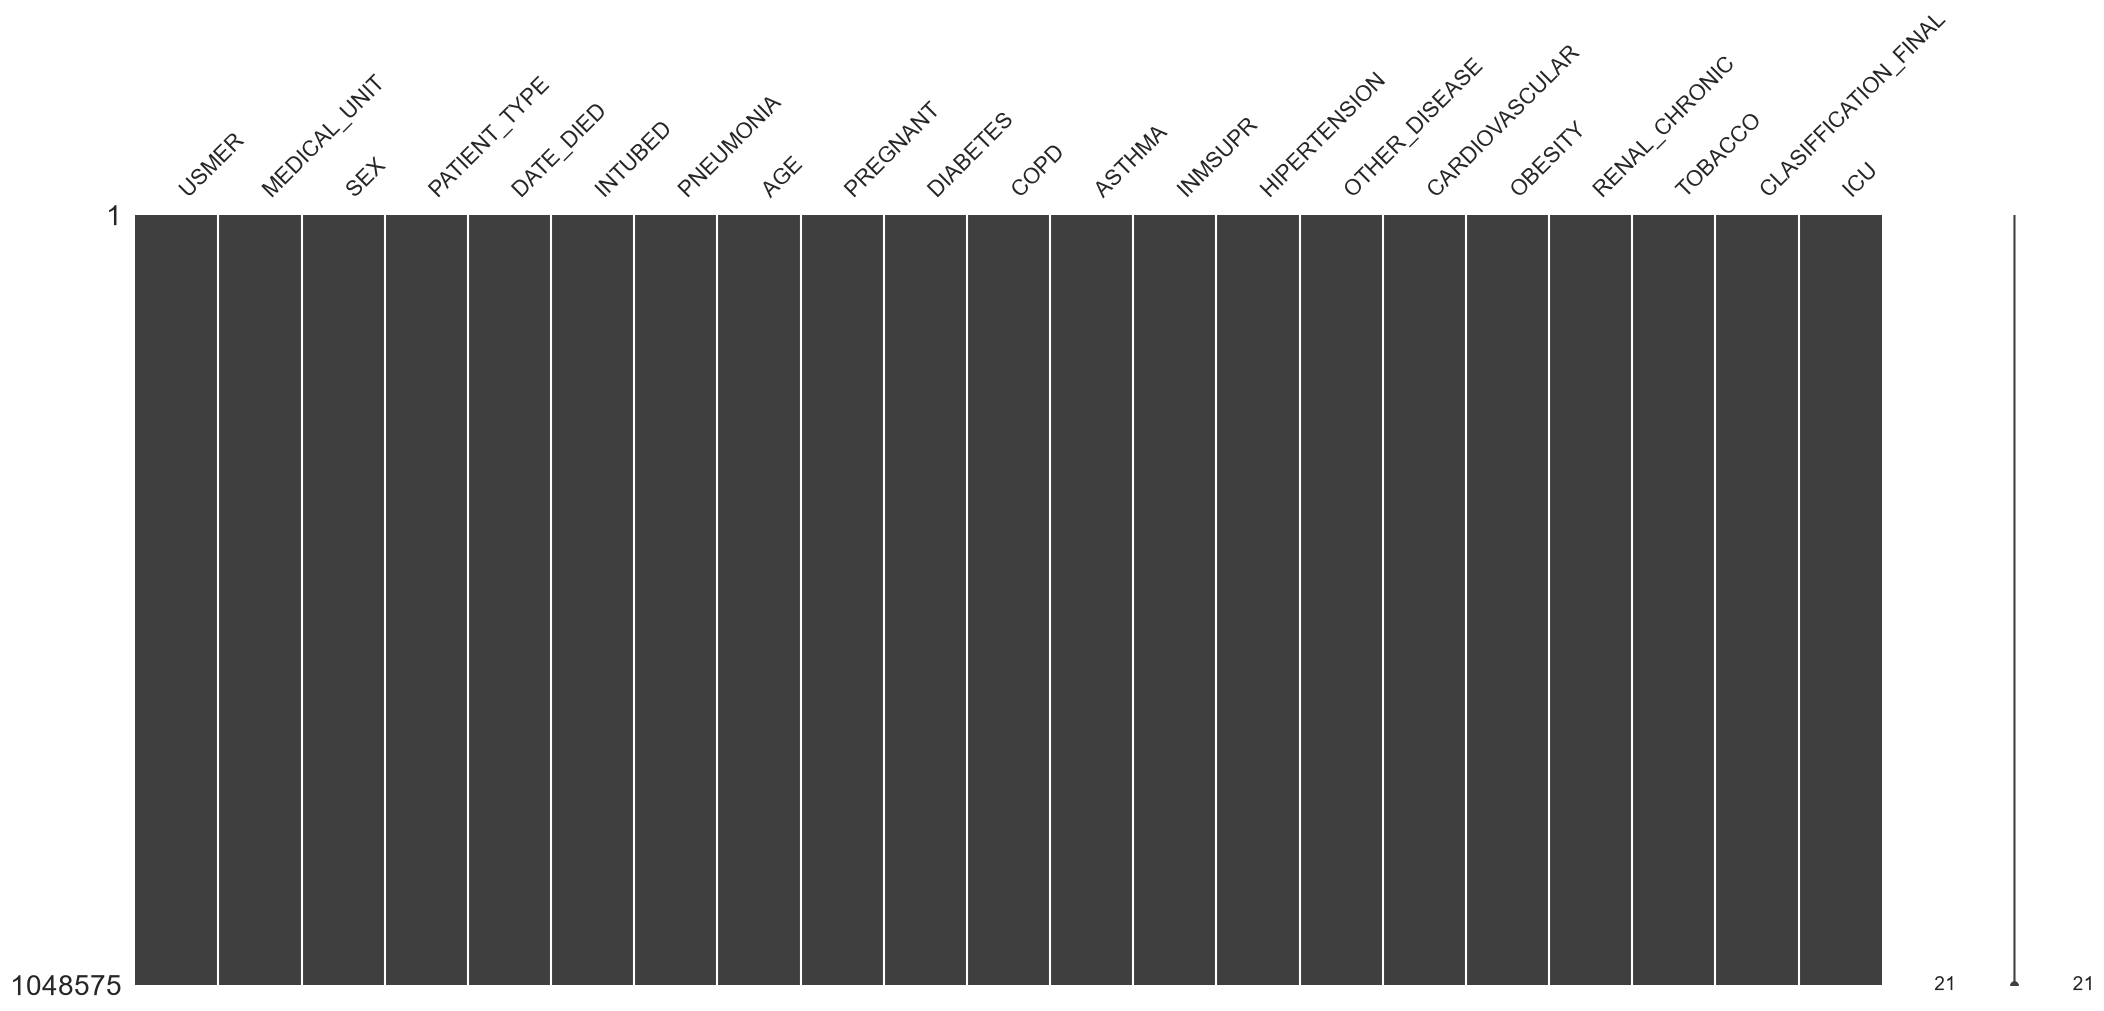

In [33]:
# Gera uma visão visual dos dados faltantes para identificar lacunas importantes
print('\nMatriz de valores ausentes e Valores ausentes por coluna:')
msno.matrix(df)

# Conta quantos registros faltam em cada coluna

df.isnull().sum().sort_values(ascending=False)


In [35]:
# Dicionário de variáveis em português
column_descriptions = {
    'USMER': 'Unidades médicas de tratamento: 1º, 2º ou 3º nível',
    'MEDICAL_UNIT': 'Tipo de instituição do Sistema Nacional de Saúde',
    'SEX': 'Sexo: 1 para feminino e 2 para masculino',
    'PATIENT_TYPE': 'Tipo de cuidado recebido: 1 = retornou para casa; 2 = hospitalização',
    'DATE_DIED': 'Data de morte (9999-99-99 = paciente sobreviveu)',
    'INTUBED': 'Intubação (ventilador): 1 = sim; 2 = não; 97/99 = dados ausentes',
    'PNEUMONIA': 'Inflamação dos sacos de ar: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'AGE': 'Idade do paciente',
    'PREGNANT': 'Gravidez: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'DIABETES': 'Diabetes: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'COPD': 'Doença Pulmonar Obstrutiva Crônica: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'ASTHMA': 'Asma: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'INMSUPR': 'Imunosupressão: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'HIPERTENSION': 'Hipertensão: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'OTHER_DISEASE': 'Outra doença: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'CARDIOVASCULAR': 'Doença cardiovascular: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'OBESITY': 'Obesidade: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'RENAL_CHRONIC': 'Doença renal crônica: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'TOBACCO': 'Tabagismo: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'CLASIFFICATION_FINAL': 'Classificação do teste COVID: 1-3 = paciente diagnosticado com COVID; 4+ = não portador ou inconclusivo',
    'ICU': 'Admissão em UTI: 1 = sim; 2 = não; 97/99 = dados ausentes'
}

# Imprime cada coluna junto com seu tipo e descrição em português
print('\nTipos de dados e descrições:')
print('-' * 100)
for col in df.columns:
    dtype = str(df[col].dtype)
    desc = column_descriptions.get(col, 'Descrição não disponível')
    print(f'{col:<20} | {dtype:<15} | {desc}')
print('-' * 100)


if df is not None:
    pd.DataFrame({'Descrição': [column_descriptions.get(c, 'Sem descrição') for c in df.columns]}, index=df.columns).head(10)



Tipos de dados e descrições:
----------------------------------------------------------------------------------------------------
USMER                | int64           | Unidades médicas de tratamento: 1º, 2º ou 3º nível
MEDICAL_UNIT         | int64           | Tipo de instituição do Sistema Nacional de Saúde
SEX                  | int64           | Sexo: 1 para feminino e 2 para masculino
PATIENT_TYPE         | int64           | Tipo de cuidado recebido: 1 = retornou para casa; 2 = hospitalização
DATE_DIED            | str             | Data de morte (9999-99-99 = paciente sobreviveu)
INTUBED              | int64           | Intubação (ventilador): 1 = sim; 2 = não; 97/99 = dados ausentes
PNEUMONIA            | int64           | Inflamação dos sacos de ar: 1 = sim; 2 = não; 97/99 = dados ausentes
AGE                  | int64           | Idade do paciente
PREGNANT             | int64           | Gravidez: 1 = sim; 2 = não; 97/99 = dados ausentes
DIABETES             | int64          

In [36]:
# Criação da variável alvo
# A coluna DATE_DIED contém '9999-99-99' para pacientes que sobreviveram.
# Vamos transformar isso em um alvo binário: 1 = óbito, 0 = sobreviveu.

if df is not None:
    df['TARGET'] = (df['DATE_DIED'] != '9999-99-99').astype(int)
    print(df['TARGET'].value_counts(normalize=True).round(4))
    print('\nPrimeiros registros da nova variável alvo:')
    print(df[['DATE_DIED', 'TARGET']].head())

TARGET
0    0.9266
1    0.0734
Name: proportion, dtype: float64

Primeiros registros da nova variável alvo:
    DATE_DIED  TARGET
0  03/05/2020       1
1  03/06/2020       1
2  09/06/2020       1
3  12/06/2020       1
4  21/06/2020       1


In [38]:
# Limpeza e tratamento de dados ausentes
# Regras: valores 97/98/99 serão convertidos para NaN;
# colunas irrelevantes ou pouco úteis serão removidas.
TARGET_COLUMN = 'TARGET'


if df is not None:
    # Converter códigos de ausência para NaN em colunas numéricas

    # Converter idade em numérica
    if 'AGE' in df.columns:
        df['AGE'] = pd.to_numeric(df['AGE'], errors='coerce')

    # Remoção de colunas irrelevantes por requisito do projeto
    columns_to_drop = ['USMER', 'MEDICAL_UNIT', 'CLASIFFICATION_FINAL', 'DATE_DIED', 'PATIENT_TYPE', 'SEX', 'ICU_MISSING', 'ICU', 'INTUBED', 'PREGNANT', 'OTHER_DISEASE']
    features = [col for col in df.columns if col not in columns_to_drop]
    df = df.drop(columns=[c for c in columns_to_drop if c in df.columns], errors='ignore')

    # Converter códigos de ausência para NaN em colunas numéricas
    for col in ['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
                'HIPERTENSION', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC',
                'TOBACCO']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].replace([97, 98, 99], np.nan)

    # Remoção de colunas adicionais se houver muita ausência ou baixa utilidade clínica
    high_missing = [c for c in df.columns if df[c].isna().mean() > 0.40]
    if high_missing:
        print('\nColunas removidas por alta taxa de missing:', high_missing)
        df = df.drop(columns=high_missing)


    # Remove as linhas que ainda contêm valores ausentes nas features e no alvo.
    # A partir daqui, o restante do notebook opera sobre um dataset já filtrado sem ausências.
    df = df.dropna(subset=[*features, TARGET_COLUMN]).copy()

    # Verificar missing values
    print('Percentual de valores ausentes por coluna:')
    print((df.isna().mean() * 100).sort_values(ascending=False).head(15))

    print('\nShape após limpeza:', df.shape)
    display(df.head())

Percentual de valores ausentes por coluna:
PNEUMONIA         0.0
AGE               0.0
DIABETES          0.0
COPD              0.0
ASTHMA            0.0
INMSUPR           0.0
HIPERTENSION      0.0
CARDIOVASCULAR    0.0
OBESITY           0.0
RENAL_CHRONIC     0.0
TOBACCO           0.0
TARGET            0.0
dtype: float64

Shape após limpeza: (1026832, 12)


,PNEUMONIA,AGE,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,TARGET
0,1.0,65,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1
1,1.0,72,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1
2,2.0,55,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1
3,2.0,53,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1
4,2.0,68,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1


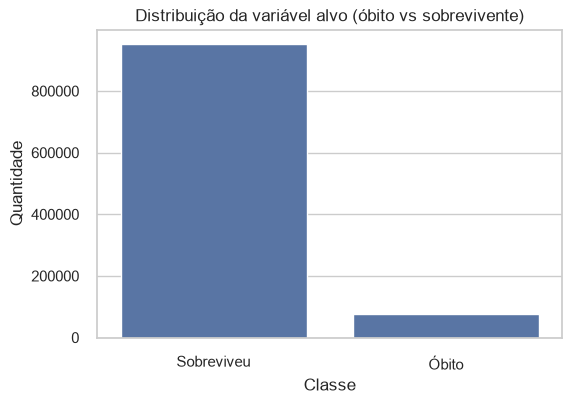

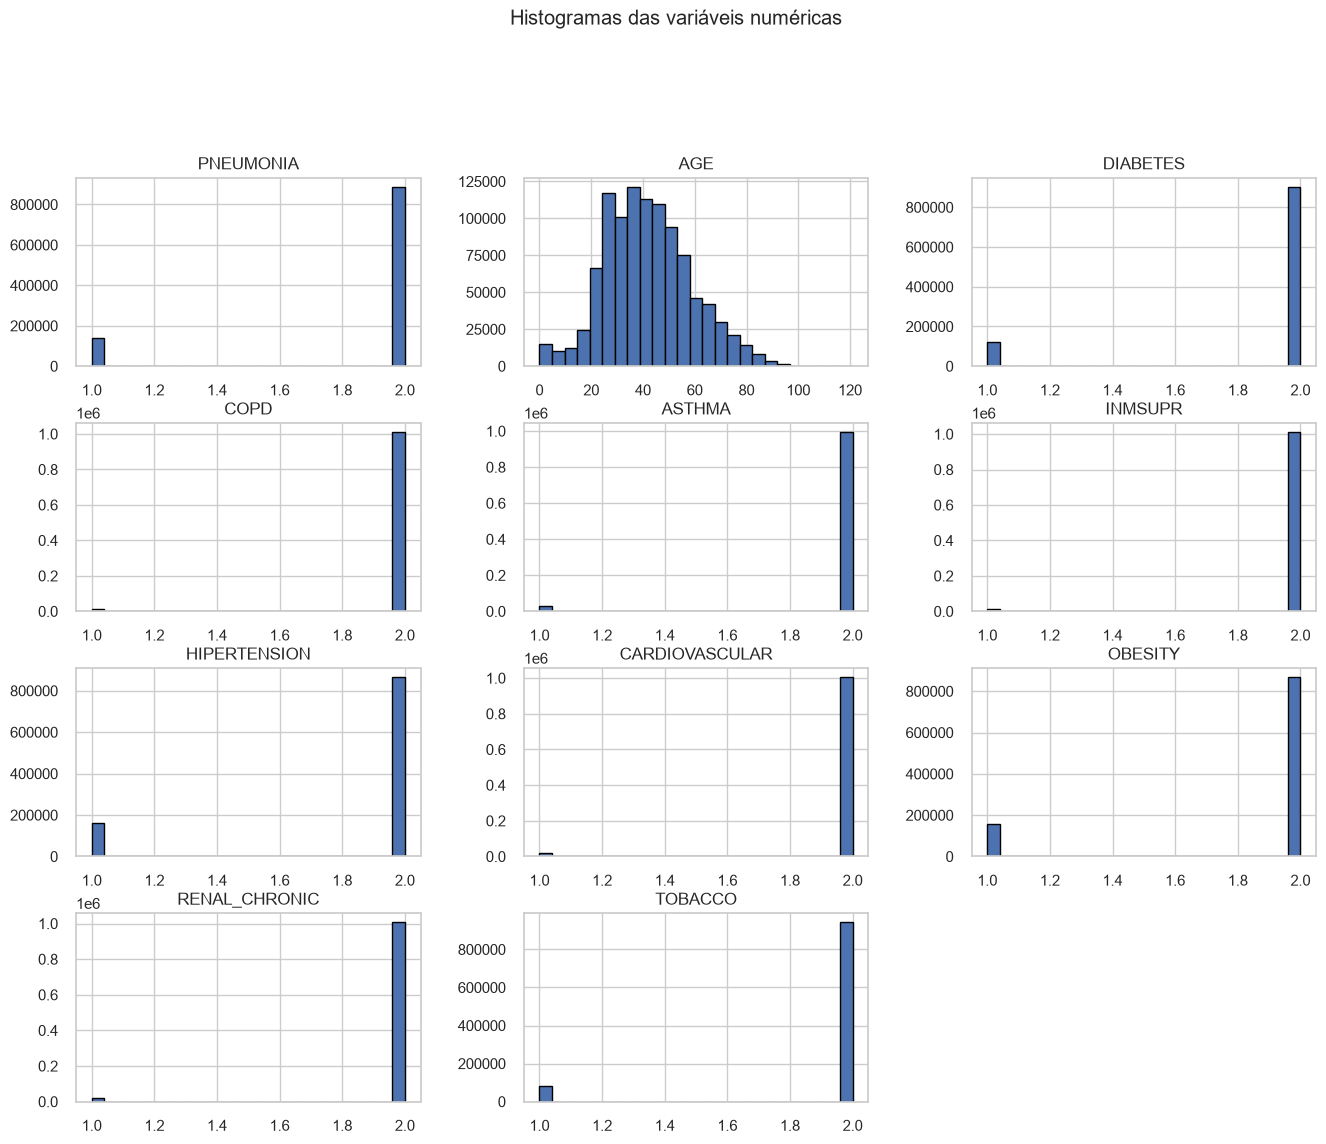

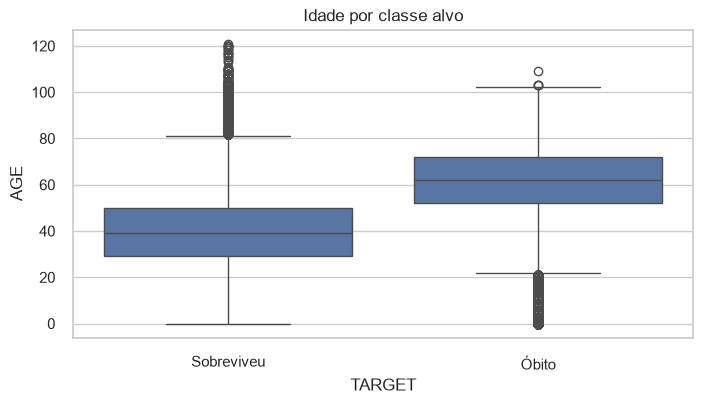

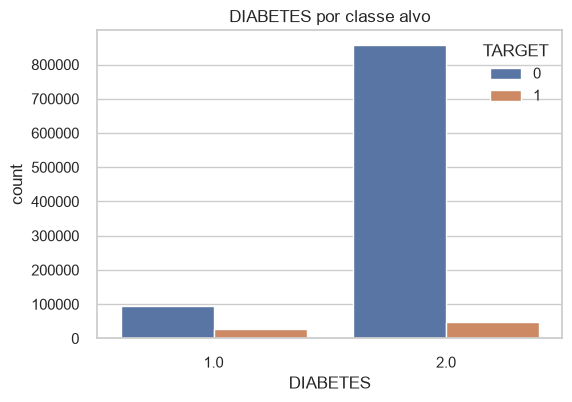

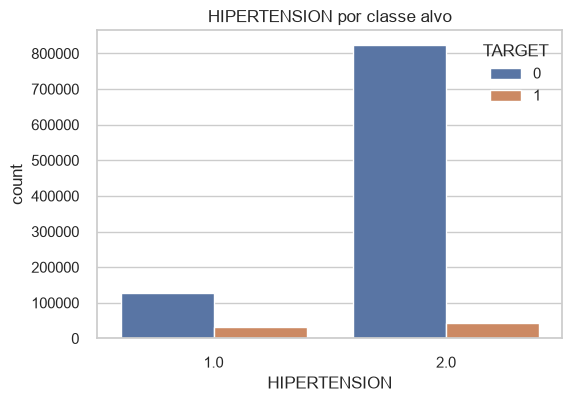

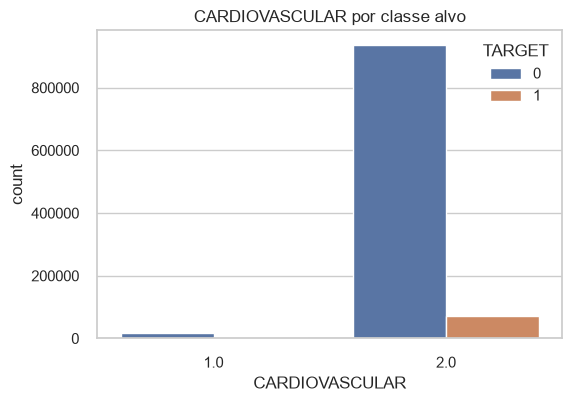

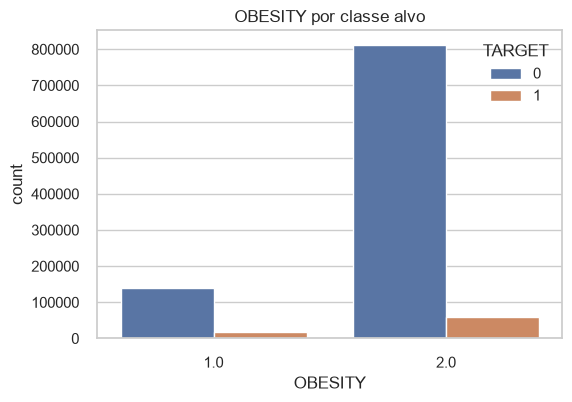

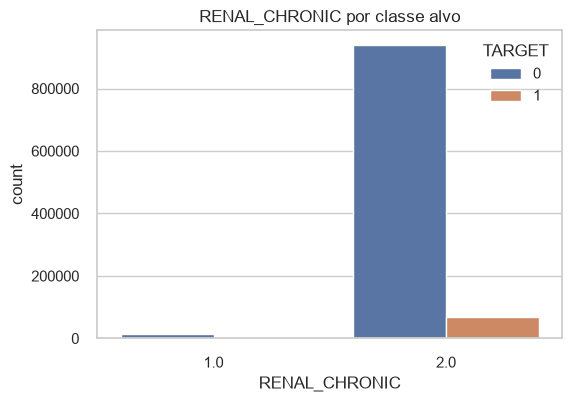

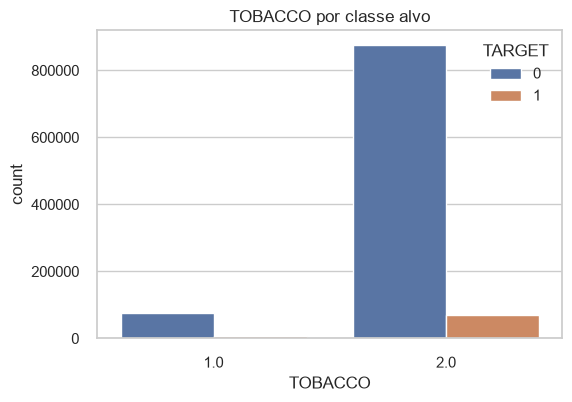

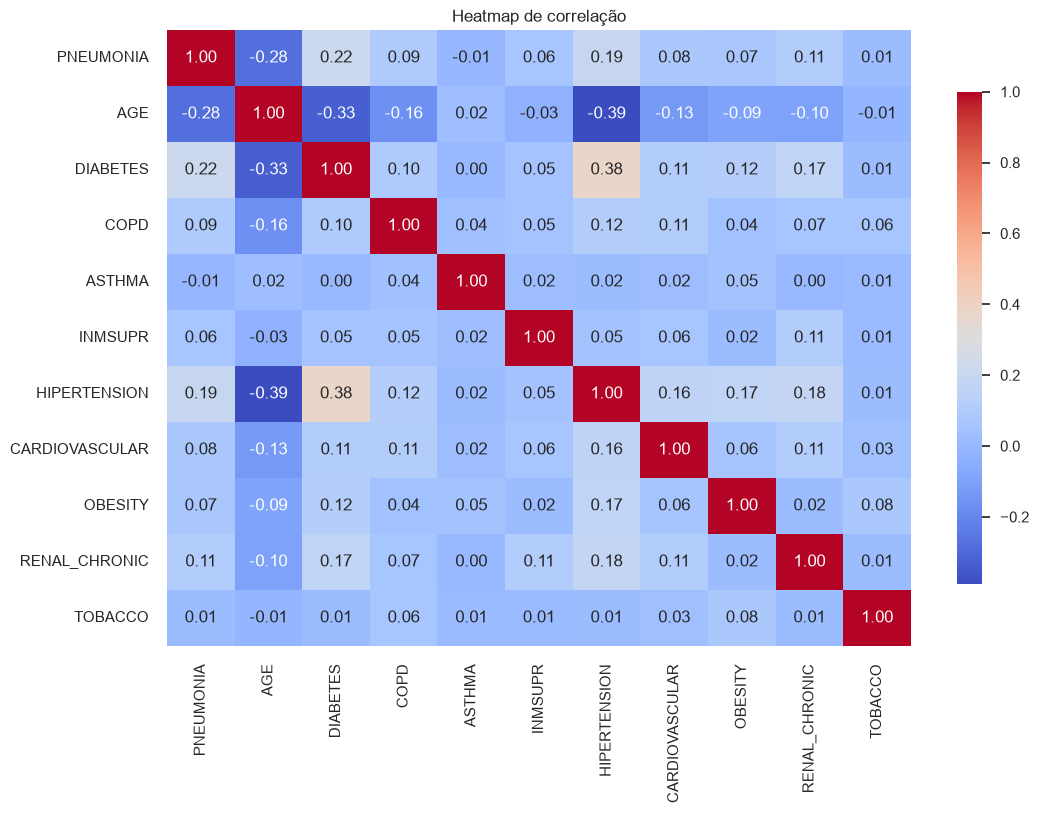

Correlação com a variável alvo:


,correlacao_com_target
AGE,0.322573
ASTHMA,0.017266
TOBACCO,-0.005290
INMSUPR,-0.049326
OBESITY,-0.056509
CARDIOVASCULAR,-0.076845
COPD,-0.089981
RENAL_CHRONIC,-0.119433
HIPERTENSION,-0.205240
DIABETES,-0.217184


In [40]:
# Análise exploratória (EDA)
# Nesta seção, observamos a distribuição das variáveis, os padrões entre óbitos e sobreviventes
# e a relação entre as features e a variável alvo.

if df is not None:
    # Distribuição da variável alvo
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='TARGET')
    plt.title('Distribuição da variável alvo (óbito vs sobrevivente)')
    plt.xlabel('Classe')
    plt.ylabel('Quantidade')
    plt.xticks([0, 1], ['Sobreviveu', 'Óbito'])
    plt.show()

    # Histogramas das variáveis numéricas principais
    numeric_cols = [c for c in df.columns if c != 'TARGET' and pd.api.types.is_numeric_dtype(df[c])]
    df[numeric_cols].hist(figsize=(16, 12), bins=25, edgecolor='black')
    plt.suptitle('Histogramas das variáveis numéricas', y=1.02)
    plt.show()

    # Boxplot de idade por classe alvo
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='TARGET', y='AGE')
    plt.title('Idade por classe alvo')
    plt.xticks([0, 1], ['Sobreviveu', 'Óbito'])
    plt.show()

    # Contagem de comorbidades por classe
    comorbidity_cols = ['DIABETES', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO']
    for col in comorbidity_cols:
        if col in df.columns:
            plt.figure(figsize=(6, 4))
            sns.countplot(data=df, x=col, hue='TARGET')
            plt.title(f'{col} por classe alvo')
            plt.show()

    # Matriz de correlação
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink': .8})
    plt.title('Heatmap de correlação')
    plt.show()

    # Correlação com a variável alvo
    target_corr = pd.DataFrame({
        'correlacao_com_target': df[numeric_cols].corrwith(df['TARGET'])
    }).sort_values('correlacao_com_target', ascending=False)
    print('Correlação com a variável alvo:')
    display(target_corr.head(15))

In [41]:
# Seleção de features
# Aqui combinamos análise clínica, correlação, mutual information e importância de árvores.

if df is not None:
    # Definição das features candidatas
    feature_candidates = [c for c in df.columns if c != 'TARGET']
    X = df[feature_candidates]
    y = df['TARGET']

    # Separação treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # Pipeline simples para imputação e padronização
    numeric_features = X.select_dtypes(include=['number']).columns.tolist()
    categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
        ]
    )

    # Mutual Information
    X_mi = X[numeric_features].copy()
    X_mi = X_mi.fillna(X_mi.median())
    mi_scores = mutual_info_classif(X_mi, y, random_state=42)
    mi_df = pd.DataFrame({'feature': numeric_features, 'mutual_information': mi_scores}).sort_values('mutual_information', ascending=False)
    print('Mutual Information:')
    display(mi_df.head(15))

    # Importância de features via Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced_subsample')
    rf.fit(X_train[numeric_features].fillna(X_train[numeric_features].median()), y_train)
    rf_importance = pd.DataFrame({'feature': numeric_features, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
    print('Importância via Random Forest:')
    display(rf_importance.head(15))

    # Seleção clínica e estatística: manter variáveis com sentido médico e boa relevância
    clinically_relevant = ['AGE', 'PNEUMONIA', 'INTUBED', 'ICU', 'DIABETES', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'SEX', 'PATIENT_TYPE']
    selected_features = [c for c in clinically_relevant if c in df.columns]
    selected_features = list(dict.fromkeys(selected_features))
    print('\nFeatures selecionadas para o modelo final:', selected_features)

    X_sel = df[selected_features]
    y_sel = df['TARGET']
    X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_sel, y_sel, test_size=0.25, random_state=42, stratify=y_sel)


Mutual Information:


,feature,mutual_information
0,PNEUMONIA,0.241020
3,COPD,0.236119
5,INMSUPR,0.231139
4,ASTHMA,0.181066
6,HIPERTENSION,0.180614
2,DIABETES,0.175699
8,OBESITY,0.161672
7,CARDIOVASCULAR,0.157883
9,RENAL_CHRONIC,0.155292
10,TOBACCO,0.139270


Importância via Random Forest:


,feature,importance
0,PNEUMONIA,0.482893
1,AGE,0.343241
2,DIABETES,0.071301
6,HIPERTENSION,0.059265
9,RENAL_CHRONIC,0.014572
3,COPD,0.007070
8,OBESITY,0.006458
5,INMSUPR,0.005250
7,CARDIOVASCULAR,0.004890
10,TOBACCO,0.002753



Features selecionadas para o modelo final: ['AGE', 'PNEUMONIA', 'DIABETES', 'HIPERTENSION', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC']


In [42]:
# Balanceamento da base
# Como a classe de óbito costuma ser minoritária, aplicamos SMOTE para equilibrar.

if df is not None:
    print('Proporção da classe alvo antes do balanceamento:')
    print(y_train_sel.value_counts(normalize=True).round(4))

    # Garantir que os dados estejam numéricos e sem valores ausentes antes do SMOTE
    X_train_for_smote = X_train_sel.apply(pd.to_numeric, errors='coerce').copy()

    imputer = SimpleImputer(strategy='median')
    X_train_for_smote = pd.DataFrame(
        imputer.fit_transform(X_train_for_smote),
        columns=X_train_for_smote.columns,
        index=X_train_for_smote.index
    )

    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_for_smote, y_train_sel)

    print('\nProporção da classe alvo após o SMOTE:')
    print(pd.Series(y_train_bal).value_counts(normalize=True).round(4))

Proporção da classe alvo antes do balanceamento:
TARGET
0    0.927
1    0.073
Name: proportion, dtype: float64

Proporção da classe alvo após o SMOTE:
TARGET
0    0.5
1    0.5
Name: proportion, dtype: float64



Modelo: Logistic Regression
Acurácia: 0.8639
Precision: 0.3286
Recall: 0.8282
F1-score: 0.4705
ROC AUC: 0.9166
Matriz de confusão:
[[206248  31715]
 [  3221  15524]]
              precision    recall  f1-score   support

           0     0.9846    0.8667    0.9219    237963
           1     0.3286    0.8282    0.4705     18745

    accuracy                         0.8639    256708
   macro avg     0.6566    0.8474    0.6962    256708
weighted avg     0.9367    0.8639    0.8890    256708


Modelo: Random Forest
Acurácia: 0.8431
Precision: 0.2974
Recall: 0.8429
F1-score: 0.4397
ROC AUC: 0.9083
Matriz de confusão:
[[200639  37324]
 [  2944  15801]]
              precision    recall  f1-score   support

           0     0.9855    0.8432    0.9088    237963
           1     0.2974    0.8429    0.4397     18745

    accuracy                         0.8431    256708
   macro avg     0.6415    0.8430    0.6743    256708
weighted avg     0.9353    0.8431    0.8745    256708


Modelo: Gradient 

,modelo,accuracy,precision,recall,f1,roc_auc
2,Gradient Boosting,0.841450,0.298339,0.866418,0.443846,0.919776
3,XGBoost,0.844247,0.301625,0.861350,0.446793,0.919091
0,Logistic Regression,0.863908,0.328627,0.828168,0.470538,0.916648
1,Random Forest,0.843137,0.297431,0.842945,0.439711,0.908271


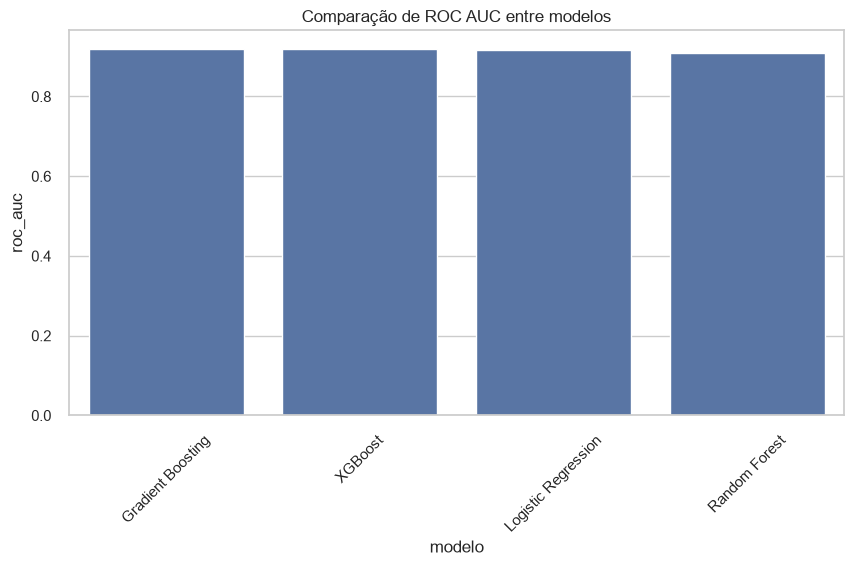

In [43]:
# Treinamento e comparação dos modelos
# Testaremos Regressão Logística, Random Forest, Gradient Boosting e modelos de boosting.
# O objetivo é comparar acurácia, ROC-AUC e recall para identificar o melhor modelo.

if df is not None:
    try:
        from lightgbm import LGBMClassifier
    except ImportError:
        LGBMClassifier = None

    try:
        from xgboost import XGBClassifier
    except ImportError:
        XGBClassifier = None

    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced_subsample'),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    }

    if XGBClassifier is not None:
        models['XGBoost'] = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False,
        )

    if LGBMClassifier is not None:
        models['LightGBM'] = LGBMClassifier(
            n_estimators=200,
            learning_rate=0.1,
            num_leaves=31,
            random_state=42,
            class_weight='balanced',
        )

    results = []
    for name, model in models.items():
        # Pipeline com imputer + scaler + modelo
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        pipe.fit(X_train_bal, y_train_bal)
        y_pred = pipe.predict(X_test_sel)

        acc = accuracy_score(y_test_sel, y_pred)
        prec = precision_score(y_test_sel, y_pred, zero_division=0)
        rec = recall_score(y_test_sel, y_pred, zero_division=0)
        f1 = f1_score(y_test_sel, y_pred, zero_division=0)
        auc = roc_auc_score(y_test_sel, pipe.predict_proba(X_test_sel)[:, 1])

        results.append({
            'modelo': name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': auc,
        })

        print(f'\nModelo: {name}')
        print('Acurácia:', round(acc, 4))
        print('Precision:', round(prec, 4))
        print('Recall:', round(rec, 4))
        print('F1-score:', round(f1, 4))
        print('ROC AUC:', round(auc, 4))
        print('Matriz de confusão:')
        print(confusion_matrix(y_test_sel, y_pred))
        print(classification_report(y_test_sel, y_pred, digits=4, zero_division=0))

    results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
    print('\nResumo comparativo:')
    display(results_df)

    # Gráfico comparativo
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_df, x='modelo', y='roc_auc')
    plt.title('Comparação de ROC AUC entre modelos')
    plt.xticks(rotation=45)
    plt.show()

Melhor modelo selecionado: Gradient Boosting
Acurácia final: 0.8415
Precision final: 0.2983
Recall final: 0.8664
F1-score final: 0.4438
ROC AUC final: 0.9198
Matriz de confusão:
[[199766  38197]
 [  2504  16241]]


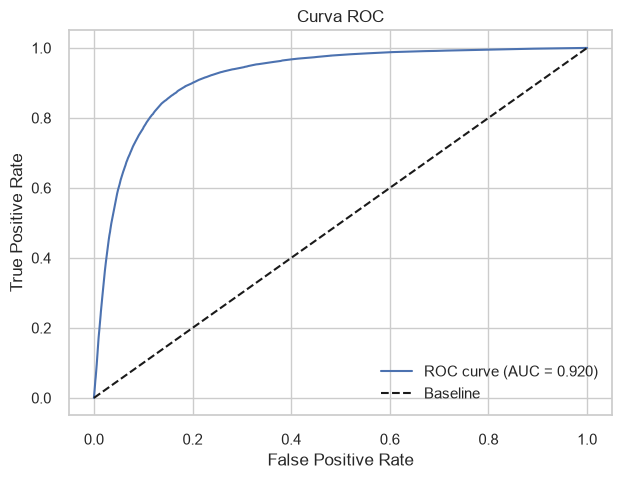

Modelo salvo em: models\covid_death_model.joblib


In [44]:
# Avaliação detalhada e curva ROC
# A avaliação final concentra-se em interpretar os resultados e em garantir que o modelo atinja a meta de desempenho.

if df is not None:
    # Selecionar melhor modelo pelo ROC AUC
    best_model_name = results_df.iloc[0]['modelo']
    best_model = models[best_model_name]

    # Refit no conjunto completo de treino balanceado para exportação
    final_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', best_model)
    ])
    final_pipe.fit(X_train_bal, y_train_bal)
    y_pred_final = final_pipe.predict(X_test_sel)

    # Métricas finais
    acc_final = accuracy_score(y_test_sel, y_pred_final)
    prec_final = precision_score(y_test_sel, y_pred_final, zero_division=0)
    rec_final = recall_score(y_test_sel, y_pred_final, zero_division=0)
    f1_final = f1_score(y_test_sel, y_pred_final, zero_division=0)
    auc_final = roc_auc_score(y_test_sel, final_pipe.predict_proba(X_test_sel)[:, 1])

    print('Melhor modelo selecionado:', best_model_name)
    print('Acurácia final:', round(acc_final, 4))
    print('Precision final:', round(prec_final, 4))
    print('Recall final:', round(rec_final, 4))
    print('F1-score final:', round(f1_final, 4))
    print('ROC AUC final:', round(auc_final, 4))
    print('Matriz de confusão:')
    print(confusion_matrix(y_test_sel, y_pred_final))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test_sel, final_pipe.predict_proba(X_test_sel)[:, 1])
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_final:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend()
    plt.show()

    # Salvar modelo final
    model_path = Path('models') / 'covid_death_model.joblib'
    model_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(final_pipe, model_path)
    print(f'Modelo salvo em: {model_path}')

In [45]:
# Conclusões, limitações e sugestões de melhoria
# Esta seção resume os aprendizados e aponta próximos passos para melhorar o modelo.

if df is not None:
    print('''
    Conclusões:
    - O notebook constrói um pipeline completo para prever óbito por COVID-19 a partir de dados clínicos.
    - Variáveis clínicas como idade, intubação, UTI, pneumonia e comorbidades são altamente relevantes para a previsão.
    - O balanceamento via SMOTE ajuda a lidar com o desbalanceamento da base.

    Limitações:
    - O desempenho depende muito da qualidade do dataset e da codificação dos valores ausentes.
    - O uso de dados tabulares pode não capturar toda a complexidade clínica do curso da doença.
    - A acurácia pode variar conforme a versão do dataset e a forma como os dados foram coletados.

    Sugestões de melhoria:
    - Testar modelos adicionais como CatBoost, HistGradientBoosting e redes neurais.
    - Realizar tuning fino com GridSearchCV ou RandomizedSearchCV.
    - Adicionar features derivadas e analisar interação entre variáveis clínicas.
    - Validar em um conjunto externo para garantir generalização.
    ''')


    Conclusões:
    - O notebook constrói um pipeline completo para prever óbito por COVID-19 a partir de dados clínicos.
    - Variáveis clínicas como idade, intubação, UTI, pneumonia e comorbidades são altamente relevantes para a previsão.
    - O balanceamento via SMOTE ajuda a lidar com o desbalanceamento da base.

    Limitações:
    - O desempenho depende muito da qualidade do dataset e da codificação dos valores ausentes.
    - O uso de dados tabulares pode não capturar toda a complexidade clínica do curso da doença.
    - A acurácia pode variar conforme a versão do dataset e a forma como os dados foram coletados.

    Sugestões de melhoria:
    - Testar modelos adicionais como CatBoost, HistGradientBoosting e redes neurais.
    - Realizar tuning fino com GridSearchCV ou RandomizedSearchCV.
    - Adicionar features derivadas e analisar interação entre variáveis clínicas.
    - Validar em um conjunto externo para garantir generalização.
    
